In [56]:

import torch
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
BASE_MODEL = "bert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [57]:
data = pd.read_csv("spam.csv",encoding='latin-1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [58]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
model = AutoModel.from_pretrained(BASE_MODEL)
model.to(device="cpu")
model

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [59]:
phrases_list = data.v2.tolist()[0:100]
inputs = tokenizer(phrases_list, return_tensors="pt", padding=True)
inputs

{'input_ids': tensor([[ 101, 2175, 2127,  ...,    0,    0,    0],
        [ 101, 7929, 2474,  ...,    0,    0,    0],
        [ 101, 2489, 4443,  ...,    0,    0,    0],
        ...,
        [ 101, 1045, 2156,  ...,    0,    0,    0],
        [ 101, 7632, 1012,  ...,    0,    0,    0],
        [ 101, 3531, 2123,  ...,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])}

In [60]:
outputs = model(**inputs)
embeddings = outputs.last_hidden_state
embeddings.shape

torch.Size([100, 85, 768])

In [61]:
mean_embeddings = embeddings.mean(axis=1)
mean_embeddings

tensor([[ 0.0616, -0.4175,  0.5915,  ..., -0.0168,  0.2059, -0.0525],
        [ 0.0210, -0.0993,  0.4202,  ...,  0.0911, -0.0220, -0.0248],
        [ 0.0131, -0.0931,  0.7313,  ..., -0.0345, -0.0058,  0.2278],
        ...,
        [ 0.2403, -0.0457,  0.5268,  ...,  0.3231,  0.1370, -0.3647],
        [ 0.1093,  0.0525,  0.7028,  ..., -0.1629, -0.0122,  0.1568],
        [ 0.0371,  0.1737,  0.2830,  ...,  0.2799, -0.1628,  0.0414]],
       grad_fn=<MeanBackward1>)

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV
import numpy as np

In [63]:
x = mean_embeddings.detach().numpy()
y = data.v1[0:100]
x_train, x_test, y_train, y_test = train_test_split(x, y)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((75, 768), (25, 768), (75,), (25,))

In [66]:
from sklearn.pipeline import Pipeline

In [77]:
params = {
    'logistic_reg_alpha': [0.01, 0.1, 1, 10],
    'logistic_reg_l1_ratio': [0.1, 0.5, 0.9]
}
pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('logistic_reg', LogisticRegression())
])
pipeline

,steps,"[('scale', ...), ('logistic_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [82]:
y_pred = pipeline.fit(x_train, y_train).predict(x_test)

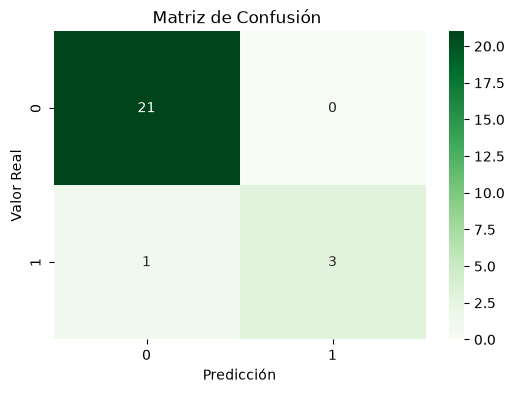

In [84]:
import seaborn as sns
from sklearn.metrics import confusion_matrix    
cm_rf = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf,annot=True,fmt="d",cmap="Greens")
plt.title("Matriz de Confusión ")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()